In [14]:
# Project: Multi-model comparison for predicting API failures from logs

# This notebook implements and compares 5 models:
# - IsolationForest (unsupervised)
# - LocalOutlierFactor (unsupervised)
# - OneClassSVM (unsupervised)
# - Dense Autoencoder (unsupervised)
# - LightGBM (supervised)
# - XGBoost (supervised)

import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import precision_recall_fscore_support, precision_recall_curve, roc_auc_score, average_precision_score,  confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, LSTM, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
import lightgbm as lgb
import xgboost as xgb
import matplotlib.pyplot as plt


In [ ]:


# ----------------------------
# Locate the data folder automatically
# ----------------------------
BASE_DIR = Path(r"D:\kaggle-telstra-network-disruptions-master")

# look for any 'data' folder inside
data_folders = list(BASE_DIR.rglob("data"))
if not data_folders:
    raise FileNotFoundError("Could not find a 'data' folder inside BASE_DIR")
DATA_DIR = data_folders[0]



In [16]:


# ----------------------------
# Load datasets
# ----------------------------
train = pd.read_csv(DATA_DIR / "train.csv")         # has id + fault_severity
logf = pd.read_csv(DATA_DIR / "log_feature.csv")    # has id + log_feature + volume


In [ ]:

# ----------------------------
# Pivot log features into wide format
# ----------------------------
X_log = logf.pivot_table(
    index="id", columns="log_feature", values="volume", fill_value=0
)


# ----------------------------
# Get labels (binary: 0 = normal, 1/2 = anomaly)
# ----------------------------
y = train.set_index("id")["fault_severity"].reindex(X_log.index)
y_binary = (y > 0).astype(int)



# ----------------------------
# Train-test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_binary, test_size=0.3, stratify=y_binary, random_state=42
)


# ----------------------------
# Scale features
# ----------------------------
scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Training time: 1.363 seconds
Prediction time: 0.163 seconds

Isolation Forest Results:
Precision: 0.151
Recall:    0.054
F1 Score:  0.079
AUC:       0.523
AUPR:      0.149


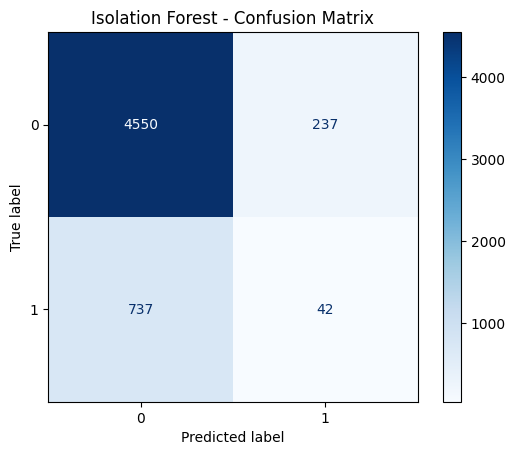

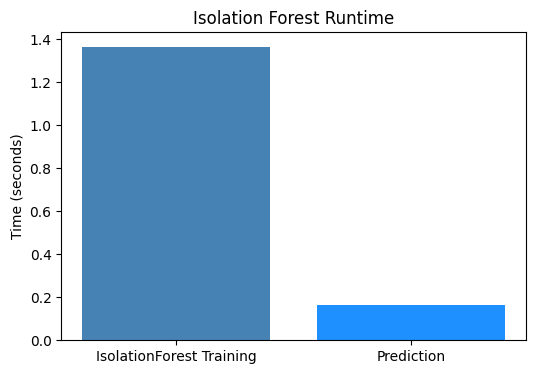

In [20]:


# ISOLATION FOREST MODEL
# ----------------------------



# ----------------------------
# 1. Train Isolation Forest (with timing)
# ----------------------------
start_train = time.time()
iso = IsolationForest(
    n_estimators=200,
    contamination=max(0.01, y_binary.mean()),  # expected anomaly rate
    random_state=42,
)
iso.fit(X_train_s)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")


# ----------------------------
# 2. Get anomaly scores & predictions (with timing)
# ----------------------------
start_pred = time.time()
scores = -iso.decision_function(X_test_s)
threshold = np.percentile(scores, 95)
y_pred = (scores >= threshold).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")


# ----------------------------
# 3. Train Isolation Forest
# ----------------------------
iso = IsolationForest(
    n_estimators=200,
    contamination=max(0.01, y_binary.mean()),  # expected anomaly rate
    random_state=42,
)
iso.fit(X_train_s)


# ----------------------------
# 4. Get anomaly scores & predictions
# ----------------------------
scores = -iso.decision_function(X_test_s)

threshold = np.percentile(scores, 95)
y_pred = (scores >= threshold).astype(int)


# ----------------------------
# 5. Evaluate metrics
# ----------------------------
p, r, f1, _ = precision_recall_fscore_support(y_test, y_pred, average="binary")
auc = roc_auc_score(y_test, scores)
aupr = average_precision_score(y_test, scores)

print("\nIsolation Forest Results:")
print(f"Precision: {p:.3f}")
print(f"Recall:    {r:.3f}")
print(f"F1 Score:  {f1:.3f}")
print(f"AUC:       {auc:.3f}")
print(f"AUPR:      {aupr:.3f}")


# ----------------------------
# 6. Confusion Matrix
# ----------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Isolation Forest - Confusion Matrix")
plt.show()

plt.figure(figsize=(6,4))
plt.bar(['IsolationForest Training', 'Prediction'],
        [train_time, pred_time],
        color=['steelblue', 'dodgerblue'])
plt.ylabel("Time (seconds)")
plt.title("Isolation Forest Runtime")
plt.show()



Training time: 1.926 seconds
Prediction time: 0.936 seconds

Local Outlier Factor Results:
Precision: 0.146
Recall:    0.053
F1 Score:  0.077
AUC:       0.522
AUPR:      0.149


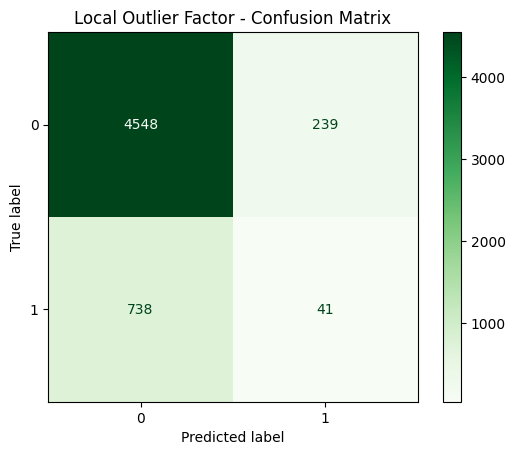

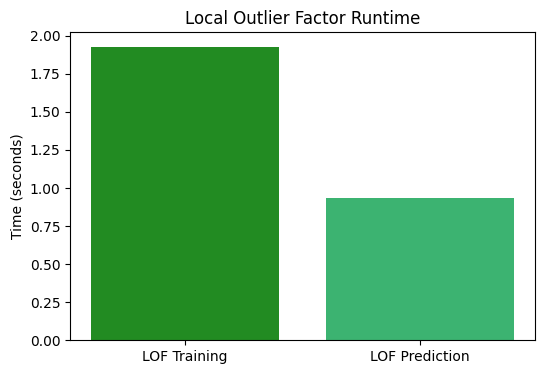

In [21]:


# LOCAL OUTLIER FACTOR MODEL
# ----------------------------



# ----------------------------
# 1. Train Local Outlier Factor with timing
# ----------------------------
start_train = time.time()
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=max(0.01, y_binary.mean()),
    novelty=True  # allows predict/decision_function on unseen data
)
lof.fit(X_train_s)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")


# ----------------------------
# 2. Get anomaly scores & predictions with timing
# ----------------------------
start_pred = time.time()
scores_lof = -lof.decision_function(X_test_s)  # higher = more anomalous
threshold_lof = np.percentile(scores_lof, 95)
y_pred_lof = (scores_lof >= threshold_lof).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")


# ----------------------------
# 3. Evaluate metrics
# ----------------------------
p_lof, r_lof, f1_lof, _ = precision_recall_fscore_support(y_test, y_pred_lof, average="binary")
auc_lof = roc_auc_score(y_test, scores_lof)
aupr_lof = average_precision_score(y_test, scores_lof)

print("\nLocal Outlier Factor Results:")
print(f"Precision: {p_lof:.3f}")
print(f"Recall:    {r_lof:.3f}")
print(f"F1 Score:  {f1_lof:.3f}")
print(f"AUC:       {auc_lof:.3f}")
print(f"AUPR:      {aupr_lof:.3f}")


# ----------------------------
# 4. Confusion Matrix
# ----------------------------
cm_lof = confusion_matrix(y_test, y_pred_lof)
disp_lof = ConfusionMatrixDisplay(confusion_matrix=cm_lof)
disp_lof.plot(cmap="Greens")
plt.title("Local Outlier Factor - Confusion Matrix")
plt.show()


# ----------------------------
# 5. Runtime Bar Chart
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['LOF Training', 'LOF Prediction'],
        [train_time, pred_time],
        color=['forestgreen','mediumseagreen'])
plt.ylabel('Time (seconds)')
plt.title('Local Outlier Factor Runtime')
plt.show()


Training time: 22.017 seconds
Prediction time: 4.952 seconds

One-Class SVM Results:
Precision: 0.197
Recall:    0.071
F1 Score:  0.104
AUC:       0.539
AUPR:      0.159


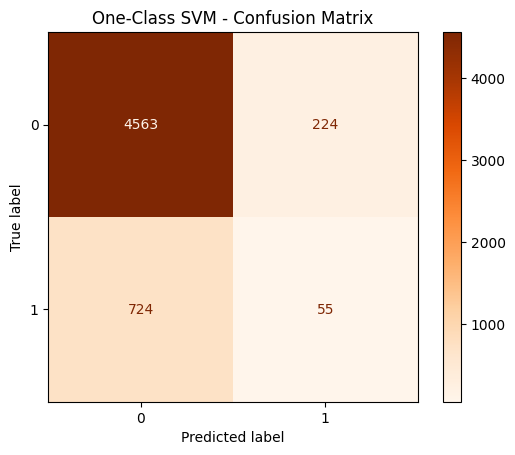

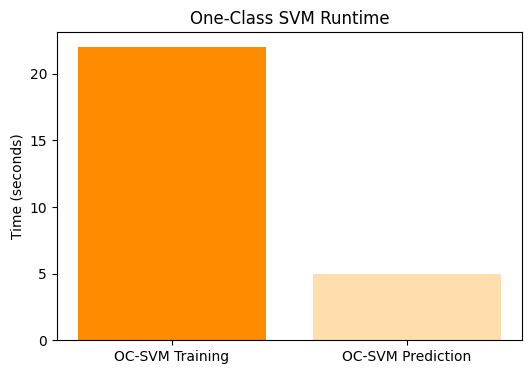

In [22]:


# ONE-CLASS SVM MODEL
# ----------------------------


# ----------------------------
# 1. Train One-Class SVM with timing
# ----------------------------
start_train = time.time()
ocsvm = OneClassSVM(
    kernel='rbf',
    gamma='scale',              # 1 / n_features
    nu=max(0.01, y_binary.mean())  # expected anomaly fraction
)
ocsvm.fit(X_train_s)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")


# ----------------------------
# 2. Get anomaly scores & predictions with timing
# ----------------------------
start_pred = time.time()
scores_ocsvm = -ocsvm.decision_function(X_test_s)  # higher = more anomalous
threshold_ocsvm = np.percentile(scores_ocsvm, 95)
y_pred_ocsvm = (scores_ocsvm >= threshold_ocsvm).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")


# ----------------------------
# 3. Evaluate metrics
# ----------------------------
p_svm, r_svm, f1_svm, _ = precision_recall_fscore_support(y_test, y_pred_ocsvm, average="binary")
auc_svm = roc_auc_score(y_test, scores_ocsvm)
aupr_svm = average_precision_score(y_test, scores_ocsvm)

print("\nOne-Class SVM Results:")
print(f"Precision: {p_svm:.3f}")
print(f"Recall:    {r_svm:.3f}")
print(f"F1 Score:  {f1_svm:.3f}")
print(f"AUC:       {auc_svm:.3f}")
print(f"AUPR:      {aupr_svm:.3f}")


# ----------------------------
# 4. Confusion Matrix
# ----------------------------
cm_svm = confusion_matrix(y_test, y_pred_ocsvm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap="Oranges")
plt.title("One-Class SVM - Confusion Matrix")
plt.show()


# ----------------------------
# 5. Runtime plot
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['OC-SVM Training', 'OC-SVM Prediction'],
        [train_time, pred_time],
        color=['darkorange','navajowhite'])
plt.ylabel('Time (seconds)')
plt.title('One-Class SVM Runtime')
plt.show()


Training time: 111.052 seconds
Prediction time: 0.825 seconds

Dense Autoencoder Results:
Precision: 0.208
Recall:    0.074
F1 Score:  0.110
AUC:       0.516
AUPR:      0.158


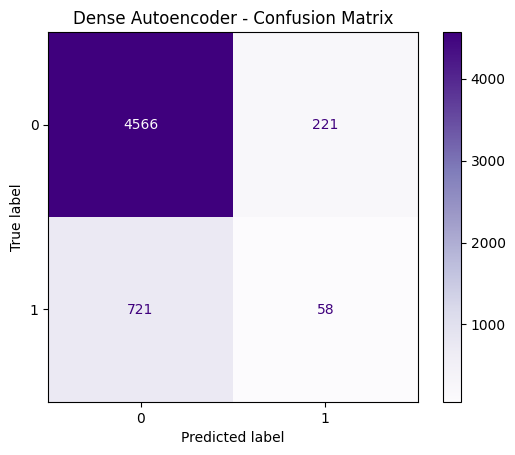

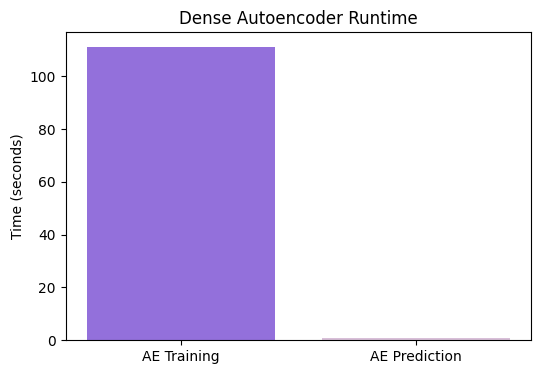

In [23]:


# DENSE AUTOENCODER MODEL
# ----------------------------



# ----------------------------
# Build Dense Autoencoder
# ----------------------------
input_dim = X_train_s.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid')
])

autoencoder.compile(optimizer='adam', loss='mse')


# ----------------------------
# Train Autoencoder with timing
# ----------------------------
start_train = time.time()
history = autoencoder.fit(
    X_train_s, X_train_s,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")


# ----------------------------
# Predict with timing
# ----------------------------
start_pred = time.time()
X_test_pred = autoencoder.predict(X_test_s, verbose=0)
reconstruction_error = np.mean(np.square(X_test_s - X_test_pred), axis=1)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")


# ----------------------------
# Threshold & Evaluate metrics
# ----------------------------
threshold_ae = np.percentile(reconstruction_error, 95)
y_pred_ae = (reconstruction_error >= threshold_ae).astype(int)

p_ae, r_ae, f1_ae, _ = precision_recall_fscore_support(y_test, y_pred_ae, average="binary")
auc_ae = roc_auc_score(y_test, reconstruction_error)
aupr_ae = average_precision_score(y_test, reconstruction_error)

print("\nDense Autoencoder Results:")
print(f"Precision: {p_ae:.3f}")
print(f"Recall:    {r_ae:.3f}")
print(f"F1 Score:  {f1_ae:.3f}")
print(f"AUC:       {auc_ae:.3f}")
print(f"AUPR:      {aupr_ae:.3f}")


# ----------------------------
# Confusion Matrix
# ----------------------------
cm_ae = confusion_matrix(y_test, y_pred_ae)
disp_ae = ConfusionMatrixDisplay(confusion_matrix=cm_ae)
disp_ae.plot(cmap="Purples")
plt.title("Dense Autoencoder - Confusion Matrix")
plt.show()


# ----------------------------
# Runtime plot
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['AE Training', 'AE Prediction'],
        [train_time, pred_time],
        color=['mediumpurple','thistle'])
plt.ylabel('Time (seconds)')
plt.title('Dense Autoencoder Runtime')
plt.show()


Training time: 0.673 seconds
Prediction time: 0.050 seconds

LightGBM Results:
Precision: 0.339
Recall:    0.050
F1 Score:  0.087
AUC:       0.735
AUPR:      0.272


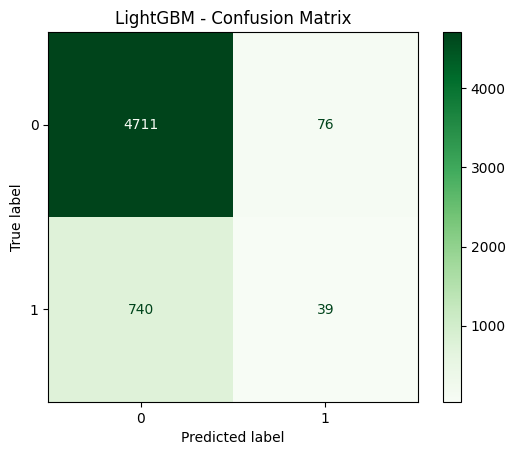

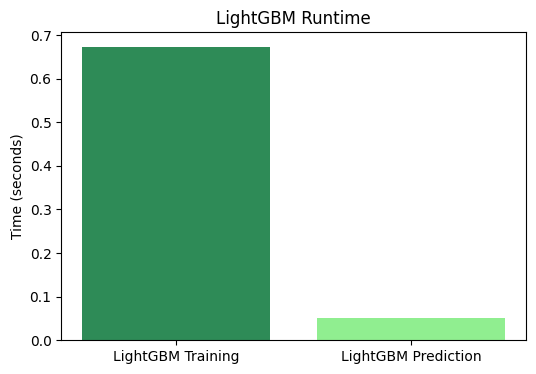

In [24]:


# LIGHTGBM MODEL
# ----------------------------



# ----------------------------
# Train LightGBM with timing
# ----------------------------
start_train = time.time()
lgb_train = lgb.Dataset(X_train_s, label=y_train)
lgb_model = lgb.train(
    params={'objective': 'binary', 'metric': 'auc', 'verbosity': -1},
    train_set=lgb_train,
    num_boost_round=200
)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")


# ----------------------------
# Predict with timing
# ----------------------------
start_pred = time.time()
y_prob_lgb = lgb_model.predict(X_test_s)
y_pred_lgb = (y_prob_lgb >= 0.5).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")


# ----------------------------
# Evaluate metrics
# ----------------------------
p_lgb, r_lgb, f1_lgb, _ = precision_recall_fscore_support(y_test, y_pred_lgb, average="binary")
auc_lgb = roc_auc_score(y_test, y_prob_lgb)
aupr_lgb = average_precision_score(y_test, y_prob_lgb)

print("\nLightGBM Results:")
print(f"Precision: {p_lgb:.3f}")
print(f"Recall:    {r_lgb:.3f}")
print(f"F1 Score:  {f1_lgb:.3f}")
print(f"AUC:       {auc_lgb:.3f}")
print(f"AUPR:      {aupr_lgb:.3f}")


# ----------------------------
# Confusion Matrix
# ----------------------------
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
disp_lgb = ConfusionMatrixDisplay(confusion_matrix=cm_lgb)
disp_lgb.plot(cmap="Greens")
plt.title("LightGBM - Confusion Matrix")
plt.show()


# ----------------------------
# Bar chart of runtime
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['LightGBM Training','LightGBM Prediction'],
        [train_time, pred_time],
        color=['seagreen','lightgreen'])
plt.ylabel('Time (seconds)')
plt.title('LightGBM Runtime')
plt.show()


d:\API failures in microservices\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:40:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Training time: 1.248 seconds
Prediction time: 0.016 seconds

XGBoost Results:
Precision: 0.250
Recall:    0.014
F1 Score:  0.027
AUC:       0.743
AUPR:      0.273


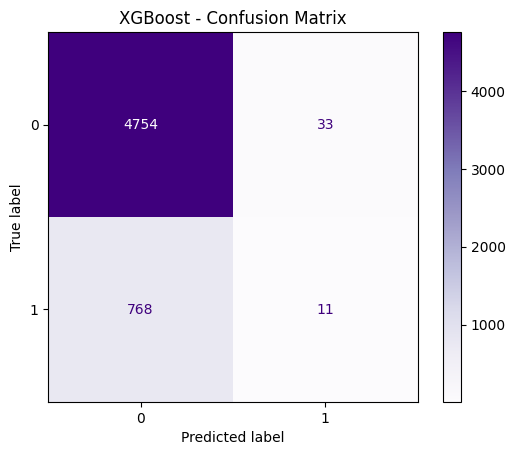

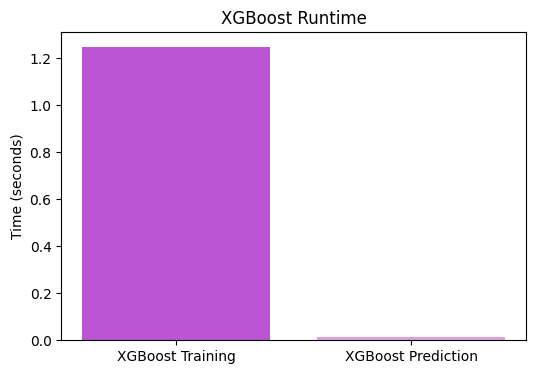

In [27]:


# XGBOOST MODEL
# ----------------------------



# ----------------------------
# Train XGBoost with timing
# ----------------------------
import time


start_train = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_s, y_train)
train_time = time.time() - start_train
print(f"Training time: {train_time:.3f} seconds")


# ----------------------------
# Predict with timing
# ----------------------------
start_pred = time.time()
y_prob_xgb = xgb_model.predict_proba(X_test_s)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.5).astype(int)
pred_time = time.time() - start_pred
print(f"Prediction time: {pred_time:.3f} seconds")


# ----------------------------
# Evaluate metrics
# ----------------------------
p_xgb, r_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average="binary")
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
aupr_xgb = average_precision_score(y_test, y_prob_xgb)

print("\nXGBoost Results:")
print(f"Precision: {p_xgb:.3f}")
print(f"Recall:    {r_xgb:.3f}")
print(f"F1 Score:  {f1_xgb:.3f}")
print(f"AUC:       {auc_xgb:.3f}")
print(f"AUPR:      {aupr_xgb:.3f}")


# ----------------------------
# Confusion Matrix
# ----------------------------
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb)
disp_xgb.plot(cmap="Purples")
plt.title("XGBoost - Confusion Matrix")
plt.show()


# ----------------------------
# (Optional) Plotting runtime
# ----------------------------
plt.figure(figsize=(6,4))
plt.bar(['XGBoost Training','XGBoost Prediction'],
        [train_time, pred_time],
        color=['mediumorchid','plum'])
plt.ylabel('Time (seconds)')
plt.title('XGBoost Runtime')
plt.show()


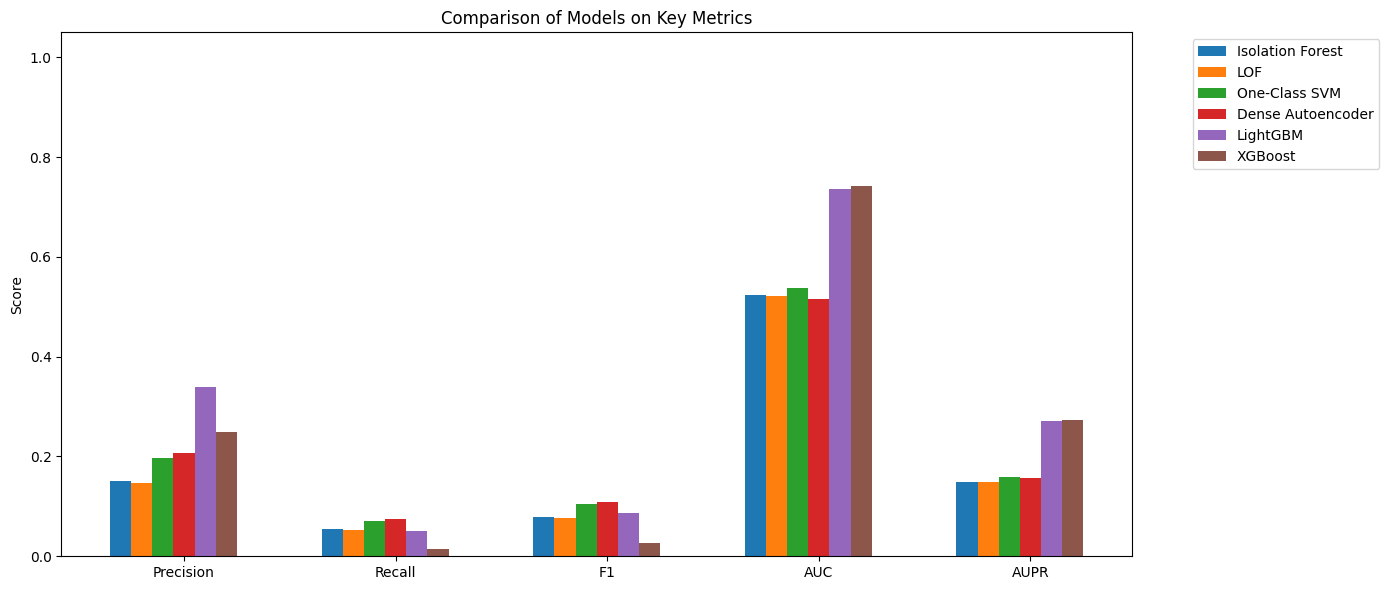

In [28]:


# COMPARISON OF EVERY MODEL
# ----------------------------



# ----------------------------
# 1. Collect metrics for all models
# ----------------------------
metrics = {
    'Isolation Forest': [p, r, f1, auc, aupr],
    'LOF': [p_lof, r_lof, f1_lof, auc_lof, aupr_lof],
    'One-Class SVM': [p_svm, r_svm, f1_svm, auc_svm, aupr_svm],
    'Dense Autoencoder': [p_ae, r_ae, f1_ae, auc_ae, aupr_ae],
    'LightGBM': [p_lgb, r_lgb, f1_lgb, auc_lgb, aupr_lgb],
    'XGBoost': [p_xgb, r_xgb, f1_xgb, auc_xgb, aupr_xgb]
}

metric_names = ['Precision', 'Recall', 'F1', 'AUC', 'AUPR']

df_metrics = pd.DataFrame(metrics, index=metric_names)


# ----------------------------
# 2. Plot grouped bar chart
# ----------------------------
fig, ax = plt.subplots(figsize=(14,6))

bar_width = 0.1
x = np.arange(len(metric_names))

for i, model in enumerate(df_metrics.columns):
    ax.bar(x + i*bar_width, df_metrics[model], width=bar_width, label=model)

ax.set_xticks(x + bar_width*len(df_metrics.columns)/2)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Comparison of Models on Key Metrics")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [32]:


# -------------------------------------------------------------------
# 1. Load & Prepare Data  (Telstra Kaggle dataset, adjust BASE_DIR)
# -------------------------------------------------------------------
BASE_DIR = Path(r"D:\kaggle-telstra-network-disruptions-master")
DATA_DIR = list(BASE_DIR.rglob("data"))[0]

train = pd.read_csv(DATA_DIR / "train.csv")
logf  = pd.read_csv(DATA_DIR / "log_feature.csv")

X_log = logf.pivot_table(index="id", columns="log_feature",
                         values="volume", fill_value=0)
y = train.set_index("id")["fault_severity"].reindex(X_log.index)
y_binary = (y > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_binary, test_size=0.3, stratify=y_binary, random_state=42
)

scaler = MinMaxScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Dictionaries to store runtimes
train_times = {}
pred_times  = {}

# -------------------------------------------------------------------
# 2. Isolation Forest
# -------------------------------------------------------------------
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    n_estimators=200,
    contamination=max(0.01, y_binary.mean()),
    random_state=42,
)

start = time.time()
iso.fit(X_train_s)
train_times["Isolation Forest"] = time.time() - start

start = time.time()
scores_iso = -iso.decision_function(X_test_s)
pred_times["Isolation Forest"] = time.time() - start

# -------------------------------------------------------------------
# 3. Dense Autoencoder
# -------------------------------------------------------------------
input_dim = X_train_s.shape[1]
autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='sigmoid')
])
autoencoder.compile(optimizer='adam', loss='mse')

start = time.time()
autoencoder.fit(
    X_train_s, X_train_s,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    verbose=0
)
train_times["Dense Autoencoder"] = time.time() - start

start = time.time()
X_test_pred = autoencoder.predict(X_test_s, verbose=0)
pred_times["Dense Autoencoder"] = time.time() - start

# -------------------------------------------------------------------
# 4. One-Class SVM
# -------------------------------------------------------------------
ocsvm = OneClassSVM(kernel='rbf', gamma='scale',
                    nu=max(0.01, y_binary.mean()))

start = time.time()
ocsvm.fit(X_train_s)
train_times["One-Class SVM"] = time.time() - start

start = time.time()
scores_svm = -ocsvm.decision_function(X_test_s)
pred_times["One-Class SVM"] = time.time() - start

# -------------------------------------------------------------------
# 5. Local Outlier Factor
# -------------------------------------------------------------------
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=max(0.01, y_binary.mean()),
    novelty=True
)

start = time.time()
lof.fit(X_train_s)
train_times["Local Outlier Factor"] = time.time() - start

start = time.time()
scores_lof = -lof.decision_function(X_test_s)
pred_times["Local Outlier Factor"] = time.time() - start

# -------------------------------------------------------------------
# 6. Plot Training & Prediction Time Comparison
# -------------------------------------------------------------------
models = list(train_times.keys())
train_vals = [train_times[m] for m in models]
pred_vals  = [pred_times[m] for m in models]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9,5))
plt.bar(x - width/2, train_vals, width, label='Training Time (s)', color='steelblue')
plt.bar(x + width/2, pred_vals,  width, label='Prediction Time (s)', color='darkorange')

plt.xticks(x, models, rotation=15)
plt.ylabel("Time (seconds)")
plt.title("Runtime Comparison of Anomaly-Detection Models")
plt.legend()
plt.tight_layout()
plt.show()

KeyboardInterrupt: 